<a href="https://colab.research.google.com/github/ravitejanene-cmd/college-project/blob/main/project_no_1house_price_prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

dependencies

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn.datasets
from sklearn.model_selection import train_test_split
from xgboost import XGBRegressor
from sklearn import metrics






importing the boston house price dataset

In [ ]:
from sklearn.datasets import fetch_california_housing
house_price_dataset = fetch_california_housing()

In [ ]:
print(house_price_dataset)

{'data': array([[   8.3252    ,   41.        ,    6.98412698, ...,    2.55555556,
          37.88      , -122.23      ],
       [   8.3014    ,   21.        ,    6.23813708, ...,    2.10984183,
          37.86      , -122.22      ],
       [   7.2574    ,   52.        ,    8.28813559, ...,    2.80225989,
          37.85      , -122.24      ],
       ...,
       [   1.7       ,   17.        ,    5.20554273, ...,    2.3256351 ,
          39.43      , -121.22      ],
       [   1.8672    ,   18.        ,    5.32951289, ...,    2.12320917,
          39.43      , -121.32      ],
       [   2.3886    ,   16.        ,    5.25471698, ...,    2.61698113,
          39.37      , -121.24      ]]), 'target': array([4.526, 3.585, 3.521, ..., 0.923, 0.847, 0.894]), 'frame': None, 'target_names': ['MedHouseVal'], 'feature_names': ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude'], 'DESCR': '.. _california_housing_dataset:\n\nCalifornia Housing dataset\n-

In [ ]:
# loading the dataset to a pandas DATAFRAME
house_price_dataframe =pd.DataFrame(house_price_dataset.data,columns = house_price_dataset.feature_names)

In [ ]:
# print first 5 rows of our DataFrame
house_price_dataframe.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25


In [ ]:
house_price_dataframe.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,price
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [ ]:
# add the target (price) column to the DataFrame
house_price_dataframe['price']= house_price_dataset.target

In [ ]:
#checking the number of rows and columns in the data frame
house_price_dataframe.shape

(20640, 9)

In [ ]:
# check for missing values
house_price_dataframe.isnull().sum()

,0
MedInc,0
HouseAge,0
AveRooms,0
AveBedrms,0
Population,0
AveOccup,0
Latitude,0
Longitude,0
price,0


In [47]:
# Load the California Housing dataset from local CSV files
train_df = pd.read_csv('/content/sample_data/california_housing_train.csv')
test_df = pd.read_csv('/content/sample_data/california_housing_test.csv')

# Combine train and test data into a single DataFrame
house_price_dataframe = pd.concat([train_df, test_df], ignore_index=True)

# Rename the target column 'median_house_value' to 'price' to match previous steps
house_price_dataframe.rename(columns={'median_house_value': 'price'}, inplace=True)

# statistical measures of the dataset
house_price_dataframe.describe()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,price
count,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000
mean,-119.566172,35.626750,28.627750,2637.051550,537.991800,1425.557650,499.525450,3.872132,207082.716750
std,2.003609,2.136141,12.582229,2176.314757,420.631119,1131.048487,381.729517,1.900356,115557.055856
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.790000,33.930000,18.000000,1451.000000,296.000000,788.000000,280.000000,2.562500,119800.000000
50%,-118.490000,34.250000,29.000000,2126.000000,434.000000,1166.000000,409.000000,3.536000,179800.000000
75%,-118.000000,37.710000,37.000000,3149.000000,647.000000,1724.000000,604.000000,4.745325,265000.000000
max,-114.310000,41.950000,52.000000,37937.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


understanding the correlation between various features in the dataset 1.postive corelation 2.negative correlation

In [ ]:
correlation =house_price_dataframe.corr()

<Axes: >

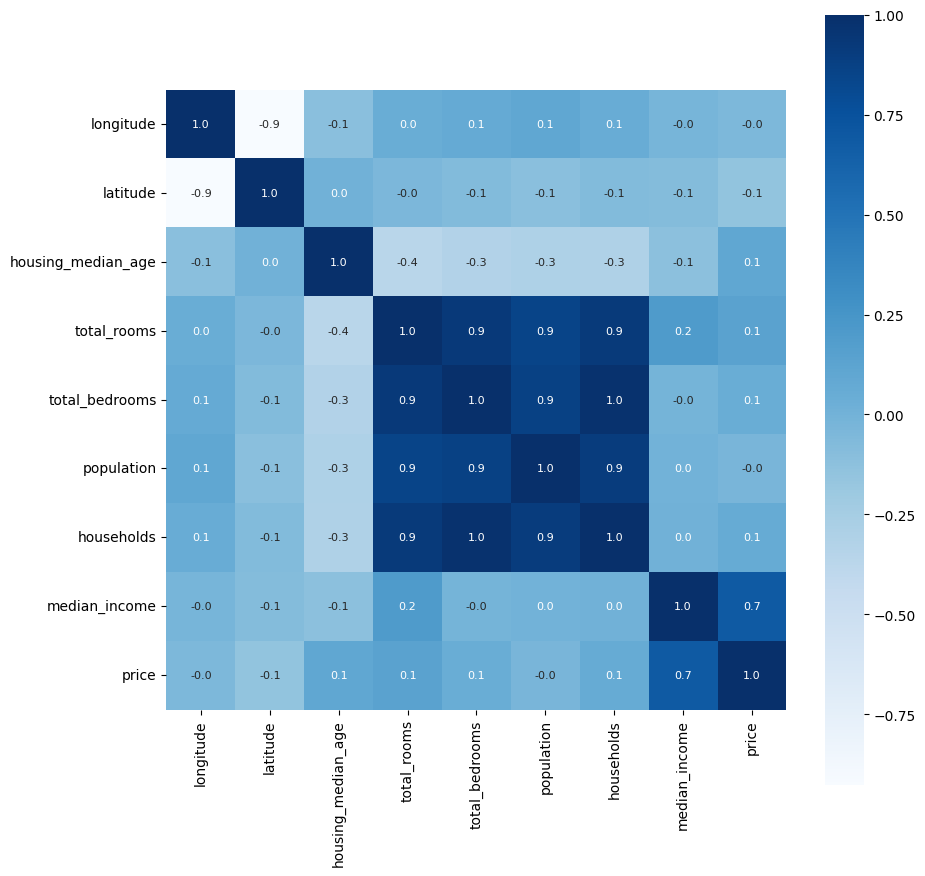

In [49]:
correlation =house_price_dataframe.corr()
# constructing a heatmap to understand the correlation
plt.figure(figsize=(10,10))
sns.heatmap(correlation,cbar=True,square=True,fmt='.1f',annot=True,annot_kws={'size':8},cmap='Blues')

splitting the data and target

In [54]:
X= house_price_dataframe.drop(['price'],axis=1)
Y= house_price_dataframe['price']


In [55]:
print(X)
print(Y)

       longitude  latitude  housing_median_age  total_rooms  total_bedrooms  \
0        -114.31     34.19                15.0       5612.0          1283.0   
1        -114.47     34.40                19.0       7650.0          1901.0   
2        -114.56     33.69                17.0        720.0           174.0   
3        -114.57     33.64                14.0       1501.0           337.0   
4        -114.57     33.57                20.0       1454.0           326.0   
...          ...       ...                 ...          ...             ...   
19995    -119.86     34.42                23.0       1450.0           642.0   
19996    -118.14     34.06                27.0       5257.0          1082.0   
19997    -119.70     36.30                10.0        956.0           201.0   
19998    -117.12     34.10                40.0         96.0            14.0   
19999    -119.63     34.42                42.0       1765.0           263.0   

       population  households  median_income  
0   

splitting the data into training data and test data

In [57]:
from sklearn.model_selection import train_test_split
X_train,X_test,Y_train,Y_test= train_test_split(X,Y,test_size=0.2,random_state=2)

In [58]:
print(X.shape,X_train.shape,X_test.shape)

(20000, 8) (16000, 8) (4000, 8)


model training
XGBoost Regressor

In [60]:
from xgboost import XGBRegressor
#loading the model
model=XGBRegressor()

In [63]:
# training the model with X_train
model.fit(X_train,Y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=None, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=None,
             n_jobs=None, num_parallel_tree=None, ...)

evaluation

prediction on training data

In [64]:
# accuracy for prediction on training data
training_data_prediction=model.predict(X_train)

In [65]:
print(training_data_prediction)

[463529.78  310707.53  312065.06  ...  63911.426 100005.1   220980.55 ]


In [67]:
from sklearn import metrics

# R squared error
score_1=metrics.r2_score(Y_train,training_data_prediction)

# mean absolute error
score_2=metrics.mean_absolute_error(Y_train,training_data_prediction)

print("R squared error:",score_1)
print("mean absolute error:",score_2)


R squared error: 0.9400133817428338
mean absolute error: 20039.704658325194


visualizing the actual prices and predicted prices

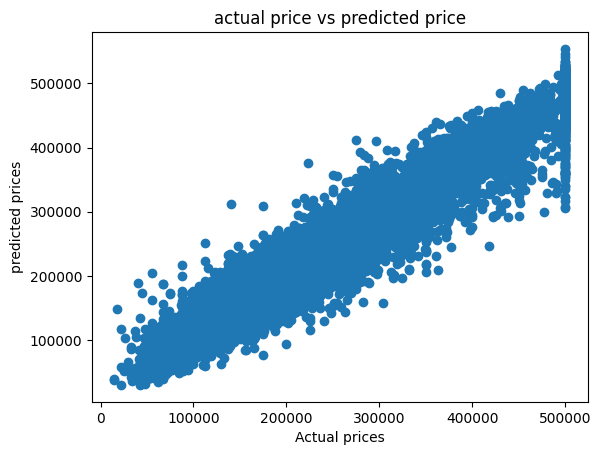

In [71]:
plt.scatter(Y_train,training_data_prediction)
plt.xlabel("Actual prices")
plt.ylabel("predicted prices")
plt.title("actual price vs predicted price")
plt.show()


prediction on test data

In [68]:
# accuracy for prediction on test data
test_data_prediction=model.predict(X_test)

In [70]:
# R squared error
score_1=metrics.r2_score(Y_test,test_data_prediction)

# mean absolute error
score_2=metrics.mean_absolute_error(Y_test,test_data_prediction)

print("R squared error:",score_1)
print("mean absolute error:",score_2)


R squared error: 0.830260411247474
mean absolute error: 32112.433140625
